In [1]:
CSV = "ideal_dataset_hourly_60d_shapefit.csv"

In [2]:
import pandas as pd

df = pd.read_csv(CSV, index_col=False)

df.head()

,timestamp,hour,phase,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane,methane_ppm,aeration_on
0,2025-01-01 00:00:00,0,active,34.81,35.74,34.17,35.25,31.69,32.64,58.05,59.93,44.78,45.51,8.80,0.00,0.0,0.0,1
1,2025-01-01 01:00:00,1,active,34.57,35.93,34.27,35.40,31.59,32.64,58.12,60.05,44.75,45.53,8.14,0.01,0.0,0.0,0
2,2025-01-01 02:00:00,2,active,34.89,35.61,34.24,35.11,31.53,32.63,57.92,60.22,44.84,45.59,8.27,0.01,0.0,0.0,0
3,2025-01-01 03:00:00,3,active,34.92,36.13,34.31,35.40,31.66,32.60,57.81,60.08,44.72,45.45,8.40,0.01,0.0,0.0,0
4,2025-01-01 04:00:00,4,active,34.41,35.84,34.11,35.21,31.54,32.57,58.01,60.02,44.86,45.58,8.51,0.01,0.0,0.0,0


In [3]:
SAVE_FIGS = False

import matplotlib.pyplot as plt
from pathlib import Path

# Ensure timestamp is datetime if present
if 'timestamp' in df.columns:
    try:
        # df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.set_index('timestamp').rolling('6h', center=True).mean().reset_index()
    except Exception:
        pass

# X-axis: prefer timestamp, else hour, else index
use_time = 'timestamp' in df.columns and pd.api.types.is_datetime64_any_dtype(df['timestamp'])
if use_time:
    x = df['timestamp']; x_label = 'Time'
else:
    x = df['hour'] if 'hour' in df.columns else df.index
    x_label = 'Hour'

# Phase cut (both forms so we can draw the right kind of marker)
if 'phase' in df.columns:
    curing_mask = df['phase'].astype(str).str.lower().eq('curing')
    if curing_mask.any():
        phase_cut_h = int(df.loc[curing_mask, 'hour'].iloc[0]) if 'hour' in df.columns else int(df.index[curing_mask][0])
        phase_cut_ts = df.loc[curing_mask, 'timestamp'].iloc[0] if use_time else None
    else:
        phase_cut_h = 14*24
        phase_cut_ts = (df['timestamp'].iloc[0] + pd.Timedelta(hours=phase_cut_h)) if use_time else None
else:
    phase_cut_h = 14*24
    phase_cut_ts = (df['timestamp'].iloc[0] + pd.Timedelta(hours=phase_cut_h)) if use_time else None

print(f"Phase change: ~{phase_cut_h} hours (~{phase_cut_h/24:.1f} days)")
if phase_cut_ts is not None:
    print(f"Phase change timestamp: {phase_cut_ts}")

Phase change: ~336 hours (~14.0 days)


In [4]:
# Marker that respects the axis type
def mark_phase(ax):
    try:
        if 'Time' == x_label and phase_cut_ts is not None:
            ax.axvline(phase_cut_ts, linestyle='--', alpha=0.6)
            ax.text(phase_cut_ts, ax.get_ylim()[1]*0.95, '  Phase change', va='top', ha='left')
        else:
            ax.axvline(phase_cut_h, linestyle='--', alpha=0.6)
            ax.text(phase_cut_h, ax.get_ylim()[1]*0.95, '  Phase change', va='top', ha='left')
    except Exception:
        pass

# Save/show helper
OUT_DIR = Path(CSV).parent
def finish(fig, name):
    fig.tight_layout()
    plt.show()


In [13]:
def smooth(y, k=12):
    import numpy as np
    return np.convolve(y, np.ones(k)/k, mode='same')

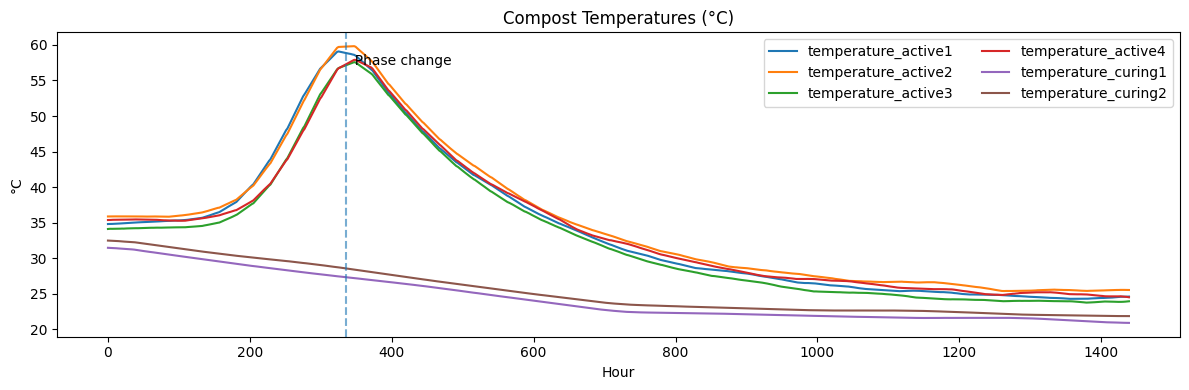

In [30]:
# 1) Temperatures
cols = [c for c in df.columns if c.startswith('temperature_')]
if cols:
    fig, ax = plt.subplots(figsize=(12, 4))
    for c in cols:
        ax.plot(x, df[c].rolling(70, center=True, min_periods=1).mean(), label=c)
    ax.set_title('Compost Temperatures (°C)')
    ax.set_xlabel(x_label); ax.set_ylabel('°C')
    ax.legend(ncol=2)
    mark_phase(ax)
    finish(fig, 'temperatures')
else:
    print('No temperature_* columns found.')


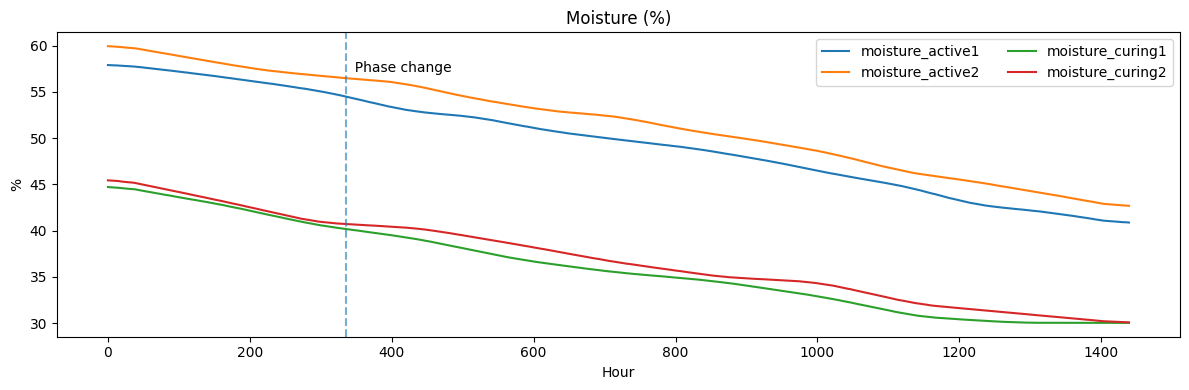

In [32]:
# 2) Moisture
cols = [c for c in df.columns if c.startswith('moisture_')]
if cols:
    fig, ax = plt.subplots(figsize=(12, 4))
    for c in cols:
        ax.plot(x, df[c].rolling(70, center=True, min_periods=1).mean(), label=c)
    ax.set_title('Moisture (%)')
    ax.set_xlabel(x_label); ax.set_ylabel('%')
    ax.legend(ncol=2)
    mark_phase(ax)
    finish(fig, 'moisture')
else:
    print('No moisture_* columns found.')


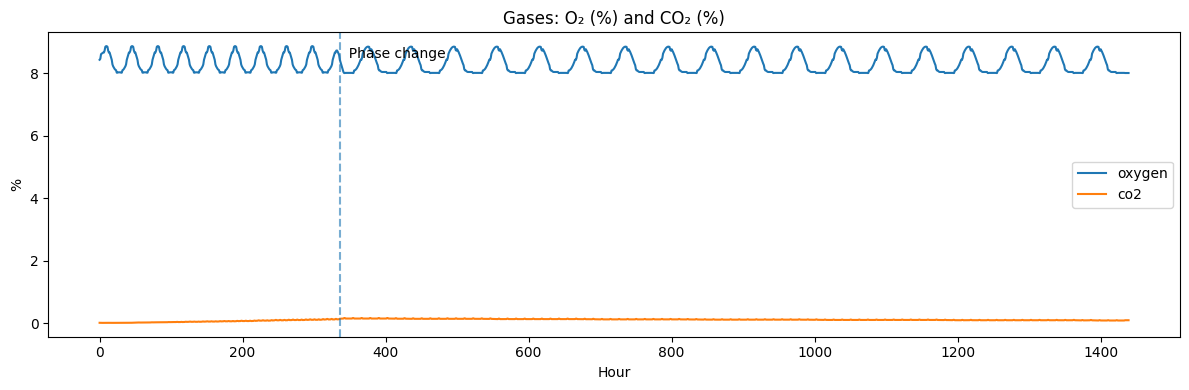

In [35]:
# 3) Gases (O2 & CO2)
cols = [c for c in ['oxygen', 'co2'] if c in df.columns]
if cols:
    fig, ax = plt.subplots(figsize=(12, 4))
    for c in cols:
        ax.plot(x, df[c].rolling(10, center=True, min_periods=1).mean(), label=c)
    ax.set_title('Gases: O₂ (%) and CO₂ (%)')
    ax.set_xlabel(x_label); ax.set_ylabel('%')
    ax.legend()
    mark_phase(ax)
    finish(fig, 'o2_co2')
else:
    print('No oxygen/co2 columns found.')


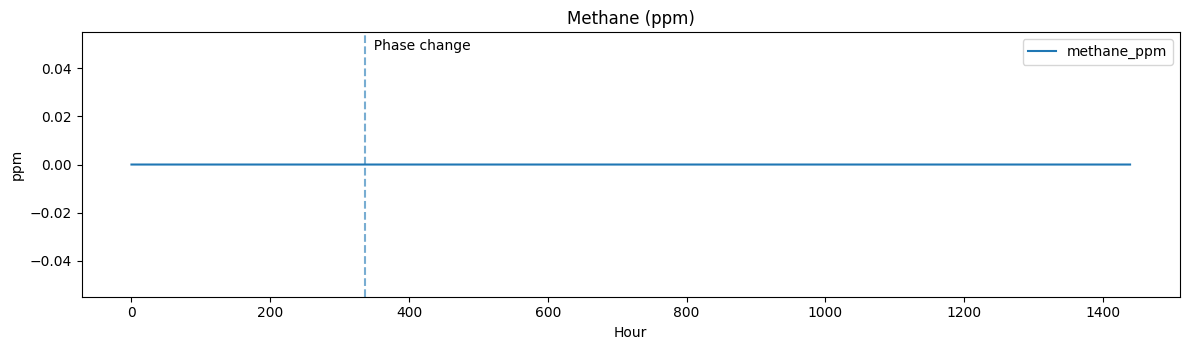

In [8]:
# 4) Methane
if 'methane_ppm' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.plot(x, df['methane_ppm'], label='methane_ppm')
    ax.set_title('Methane (ppm)')
    ax.set_xlabel(x_label); ax.set_ylabel('ppm')
    ax.legend()
    mark_phase(ax)
    finish(fig, 'methane')
else:
    print('No methane_ppm column found.')


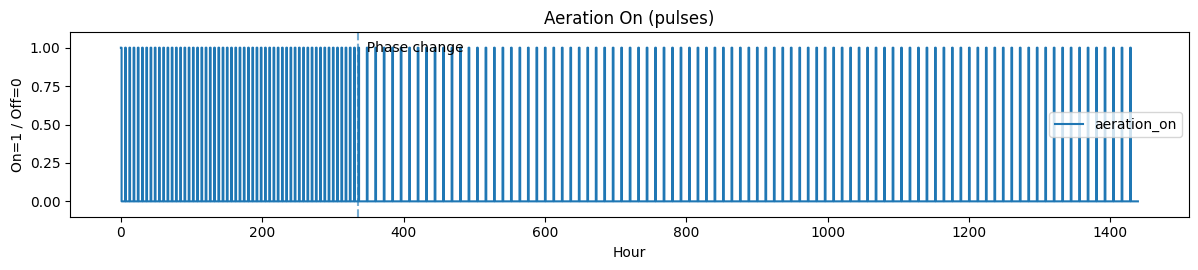

In [9]:
# 5) Aeration pulses
if 'aeration_on' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 2.8))
    ax.step(x, df['aeration_on'], where='post', label='aeration_on')
    ax.set_ylim(-0.1, 1.1)
    ax.set_title('Aeration On (pulses)')
    ax.set_xlabel(x_label); ax.set_ylabel('On=1 / Off=0')
    ax.legend()
    mark_phase(ax)
    finish(fig, 'aeration')
else:
    print('No aeration_on column found.')
